# Harris Corner Detection

### Import resources and display image

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


%matplotlib inline

In [2]:
IMG = f'../../../img'

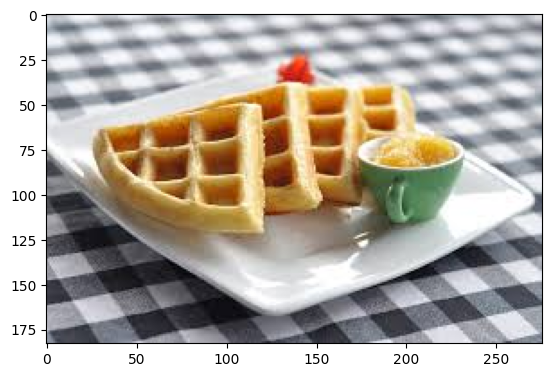

In [3]:
image = cv2.imread(f'{IMG}/waffle.jpg')
image_copy = np.copy(image)
image_copy = cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB)
plt.imshow(image_copy);

### Detect corners

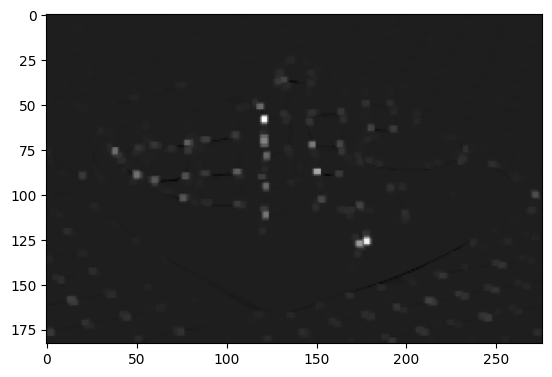

In [8]:
gray = cv2.cvtColor(image_copy, cv2.COLOR_RGB2GRAY)
gray = np.float32(gray)
dst = cv2.cornerHarris(gray, 3, 3, 0.04)
# Dilate corner image to enhance corner points
dst = cv2.dilate(dst, None)
plt.imshow(dst, cmap='gray');

### Extract and display strong corners

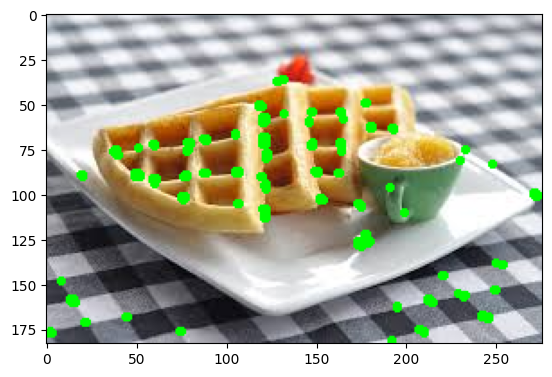

In [10]:
## TODO: Define a threshold for extracting strong corners
# This value vary depending on the image and how many corners you want to detect
# Try changing this free parameter, 0.1, to be larger or smaller ans see what happens
thresh = 0.07 * dst.max()
corner_image = np.copy(image_copy)
# Iterate through all the corners and draw them on the image (if they pass the threshold)
for j in range(dst.shape[0]):
    for i in range(dst.shape[1]):
        if(dst[j, i] > thresh):
            # image, center pt, radius, color, thickness
            cv2.circle( corner_image, (i, j), 1, (0, 255, 0), 1)
plt.imshow(corner_image);